In [3]:
from __future__ import annotations

import ast, json
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Mapping, Optional

import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt

#### Interpreter function

In [5]:
@dataclass(frozen=True)
class InterpretThresholds:
    # General Bayesian support thresholds
    ppd_sig: float = 0.95
    rope_low: float = 0.05
    rope_high: float = 0.95

    # Transition-level CN effect support
    dose_prob_sens: float = 0.95
    dose_prob_ins: float = 0.95

    # Deviation near-proportional support
    dev_small_prob: float = 0.75

    # Explicit DC posterior support if available
    dc_prob: float = 0.95

    # CI thresholds
    cancel_threshold: float = 0.10
    overcomp_threshold: float = 1.00
    hyper_threshold: float = 0.50

    # Numerical stability
    min_scaling_abs: float = 1e-3

    # Fallback for deviation if posterior ROPE prob is unavailable
    dev_abs_fallback: float = 0.50

    # Minimum number of supported transitions needed before calling Mixed
    min_supported_for_mixed: int = 2

    # DIG-like thresholds
    frac_small_gain: float = 0.15
    frac_small_loss: float = 0.15
    frac_small_amp: float = 0.25

    # Low-CN threshold for UNC-lowCN
    low_cn_aneup_threshold: int = 10


###---------------- Helpers ----------------###

def _get(res: Mapping[str, Any], key: str, default: Any = np.nan) -> Any:
    return res.get(key, default)


def _is_nan_like(x: Any) -> bool:
    return pd.isna(x) and not isinstance(x, (list, tuple, dict))


def _is_finite_number(x: Any) -> bool:
    try:
        return np.isfinite(x)
    except Exception:
        return False


def normalize_subtype_levels(x: Any) -> List[str]:
    if x is None or _is_nan_like(x):
        return []

    if isinstance(x, (list, tuple)):
        return [str(v) for v in x]

    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []

        if x.startswith("[") and x.endswith("]"):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, (list, tuple)):
                    return [str(v) for v in parsed]
            except Exception:
                pass

        return [x]

    return []


def infer_num_subtypes(res: Mapping[str, Any], default: int = 2) -> int:
    found = set()

    for key in res.keys():
        if "_s" not in key:
            continue
        try:
            suffix = key.split("_s")[-1]
            digits = ""
            for ch in suffix:
                if ch.isdigit():
                    digits += ch
                else:
                    break
            if digits:
                found.add(int(digits))
        except Exception:
            continue

    return max(found) if found else default


def subtype_name(s: int, subtype_levels: List[str]) -> str:
    if 1 <= s <= len(subtype_levels):
        return str(subtype_levels[s - 1])
    return f"s{s}"


def supported_effect(ppd_val: Any, rope_val: Any, th: InterpretThresholds) -> bool:
    if _is_finite_number(ppd_val) and _is_finite_number(rope_val):
        return (ppd_val >= th.ppd_sig) and (rope_val <= th.rope_low)
    if _is_finite_number(ppd_val):
        return ppd_val >= th.ppd_sig
    return False


def ci_from_transition(dev_val: Any, scaling_val: Any, min_scaling_abs: float) -> float:
    if _is_finite_number(dev_val) and _is_finite_number(scaling_val) and abs(scaling_val) > min_scaling_abs:
        return dev_val / abs(scaling_val)
    return np.nan


###---------------- Baseline DE ----------------###

def interpret_baseline_de(
    res: Mapping[str, Any],
    th: InterpretThresholds,
) -> Dict[str, Any]:
    ppd_tumor = _get(res, "ppd_tumor", np.nan)
    p_rope_tumor = _get(res, "p_rope_tumor", np.nan)

    if _is_finite_number(ppd_tumor) and _is_finite_number(p_rope_tumor):
        if ppd_tumor >= th.ppd_sig and p_rope_tumor <= th.rope_low:
            de_status = "DE"
        elif p_rope_tumor >= th.rope_high:
            de_status = "DE-null"
        else:
            de_status = "DE-uncertain"
    else:
        de_status = "DE-uncertain"

    return {
        "de_status": de_status,
        "ppd_tumor": ppd_tumor,
        "p_rope_tumor": p_rope_tumor,
        "tumor0_lfc_median": _get(res, "tumor0_lfc_median", np.nan),
        "tumor0_lfc_q025": _get(res, "tumor0_lfc_q025", np.nan),
        "tumor0_lfc_q975": _get(res, "tumor0_lfc_q975", np.nan),
    }


###---------------- Rewiring ----------------###

def interpret_rewiring(
    res: Mapping[str, Any],
    th: InterpretThresholds,
) -> Dict[str, Any]:
    ppd_scaling = _get(res, "ppd_scaling", np.nan)
    ppd_dev = _get(res, "ppd_dev", np.nan)

    p_rope_scaling = _get(res, "p_rope_scaling", np.nan)
    p_rope_dev = _get(res, "p_rope_dev", np.nan)

    scaling_rewired = supported_effect(ppd_scaling, p_rope_scaling, th)
    dev_rewired = supported_effect(ppd_dev, p_rope_dev, th)

    if scaling_rewired and dev_rewired:
        rewiring_status = "rewired:scaling+deviation"
    elif scaling_rewired:
        rewiring_status = "rewired:scaling"
    elif dev_rewired:
        rewiring_status = "rewired:deviation"
    else:
        rewiring_status = "not_rewired"

    return {
        "rewiring_status": rewiring_status,
        "ppd_scaling": ppd_scaling,
        "ppd_dev": ppd_dev,
        "p_rope_scaling": p_rope_scaling,
        "p_rope_dev": p_rope_dev,
        "delta_scaling_median": _get(res, "delta_scaling_median", np.nan),
        "delta_scaling_q025": _get(res, "delta_scaling_q025", np.nan),
        "delta_scaling_q975": _get(res, "delta_scaling_q975", np.nan),
        "delta_dev_median": _get(res, "delta_dev_median", np.nan),
        "delta_dev_q025": _get(res, "delta_dev_q025", np.nan),
        "delta_dev_q975": _get(res, "delta_dev_q975", np.nan),
    }


###------------Subtype pattern summary -------------###

def summarize_subtype_patterns(
    transition_groups: List[str],
    th: InterpretThresholds,
) -> Dict[str, Any]:
    supported_groups = [g for g in transition_groups if g in {"dsg", "dcg", "hag"}]
    unique_supported = sorted(set(supported_groups))

    if len(supported_groups) >= th.min_supported_for_mixed and len(unique_supported) >= 2:
        return {
            "response_class": "Mixed",
            "response_reason": "conflicting_supported_transition_patterns",
        }

    if len(unique_supported) == 1:
        mapping = {"dsg": "DSG", "dcg": "DCG", "hag": "HYPER"}
        return {
            "response_class": mapping[unique_supported[0]],
            "response_reason": f"dominant_{unique_supported[0]}",
        }

    if all(g == "null" for g in transition_groups):
        return {
            "response_class": "Null",
            "response_reason": "all_transitions_null",
        }

    return {
        "response_class": "UNC",
        "response_reason": "insufficient_or_inconsistent_support",
    }


###-------------Per-subtype dosage interpretation-------------###

def interpret_subtype_dosage(
    res,
    s,
    subtype_levels,
    th,
):
    name = subtype_name(s, subtype_levels)

    # gain: 2 -> 3
    p_gain_pos = _get(res, f"p_fracCN_2to3_pos_s{s}", np.nan)
    p_gain_rope = _get(res, f"p_rope_fracCN_2to3_s{s}", np.nan)
    frac23 = _get(res, f"fracCN_2to3_s{s}_median", np.nan)

    # amplification: 2 -> 4
    p_amp_pos = _get(res, f"p_fracCN_2to4_pos_s{s}", np.nan)
    p_amp_rope = _get(res, f"p_rope_fracCN_2to4_s{s}", np.nan)
    frac24 = _get(res, f"fracCN_2to4_s{s}_median", np.nan)

    # loss: 2 -> 1
    p_loss_neg = _get(res, f"p_fracCN_2to1_neg_s{s}", np.nan)
    p_loss_rope = _get(res, f"p_rope_fracCN_2to1_s{s}", np.nan)
    frac21 = _get(res, f"fracCN_2to1_s{s}_median", np.nan)

    # subtype-level coefficients
    b_scaling = _get(res, f"b_scaling_s{s}_median", np.nan)
    b_dev = _get(res, f"b_deviation_s{s}_median", np.nan)
    p_dev_small = _get(res, f"p_rope_bdev_s{s}", np.nan)

    # transition-level scaling / deviation summaries
    lp_scaling_21 = _get(res, f"lp_scaling_2to1_s{s}_median", np.nan)
    lp_scaling_23 = _get(res, f"lp_scaling_2to3_s{s}_median", np.nan)
    lp_scaling_24 = _get(res, f"lp_scaling_2to4_s{s}_median", np.nan)

    lp_dev_21 = _get(res, f"lp_dev_2to1_s{s}_median", np.nan)
    lp_dev_23 = _get(res, f"lp_dev_2to3_s{s}_median", np.nan)
    lp_dev_24 = _get(res, f"lp_dev_2to4_s{s}_median", np.nan)

    # support / null
    gain_supported = _is_finite_number(p_gain_pos) and (p_gain_pos >= th.dose_prob_sens)
    amp_supported = _is_finite_number(p_amp_pos) and (p_amp_pos >= th.dose_prob_sens)
    loss_supported = _is_finite_number(p_loss_neg) and (p_loss_neg >= th.dose_prob_sens)

    gain_null = _is_finite_number(p_gain_rope) and (p_gain_rope >= th.dose_prob_ins)
    amp_null = _is_finite_number(p_amp_rope) and (p_amp_rope >= th.dose_prob_ins)
    loss_null = _is_finite_number(p_loss_rope) and (p_loss_rope >= th.dose_prob_ins)

    # cancellation index
    ci23 = _get(res, f"cancel_index_2to3_s{s}_median", np.nan)
    ci24 = _get(res, f"cancel_index_2to4_s{s}_median", np.nan)
    ci21 = _get(res, f"cancel_index_2to1_s{s}_median", np.nan)

    def _ci_fallback(ci_val, lp_dev, lp_scaling):
        if _is_finite_number(ci_val):
            return ci_val
        if (
            _is_finite_number(lp_dev)
            and _is_finite_number(lp_scaling)
            and abs(lp_scaling) > th.min_scaling_abs
        ):
            return lp_dev / abs(lp_scaling)
        return np.nan

    ci23 = _ci_fallback(ci23, lp_dev_23, lp_scaling_23)
    ci24 = _ci_fallback(ci24, lp_dev_24, lp_scaling_24)
    ci21 = _ci_fallback(ci21, lp_dev_21, lp_scaling_21)

    scaling_stable_23 = _is_finite_number(lp_scaling_23) and (abs(lp_scaling_23) > th.min_scaling_abs)
    scaling_stable_24 = _is_finite_number(lp_scaling_24) and (abs(lp_scaling_24) > th.min_scaling_abs)
    scaling_stable_21 = _is_finite_number(lp_scaling_21) and (abs(lp_scaling_21) > th.min_scaling_abs)

    scaling_stable_any = (
        scaling_stable_21
        or scaling_stable_23
        or scaling_stable_24
        or (_is_finite_number(b_scaling) and abs(b_scaling) > th.min_scaling_abs)
    )

    # deviation practically small
    if _is_finite_number(p_dev_small):
        small_dev = p_dev_small >= th.dev_small_prob
        small_dev_method = "posterior_prob"
    elif _is_finite_number(b_dev):
        small_dev = abs(b_dev) <= th.dev_abs_fallback
        small_dev_method = "median_fallback"
    else:
        small_dev = False
        small_dev_method = "unavailable"

    # transition classifier
    def classify_transition(ci, supported, is_null, transition, scaling_stable, small_dev, th, frac_median):
        if is_null:
            return "null"
    
        # Hybrid support (posterior + effect size)
        if not supported:
            if _is_finite_number(frac_median):
                if transition in ("2to3", "2to4"):
                    if abs(frac_median) > th.frac_small_gain:
                        supported = True
                    else:
                        return "weak"
                elif transition == "2to1":
                    if abs(frac_median) > th.frac_small_loss:
                        supported = True
                    else:
                        return "weak"
                else:
                    return "weak"
            else:
                return "weak"

        if not scaling_stable:
            return "weak"

        if not _is_finite_number(ci):
            return "weak"

        # Gains / amplification
        if transition in ("2to3", "2to4"):
            if ci < -th.overcomp_threshold:
                return "overcomp"
            if ci < -th.cancel_threshold:
                return "buffered"
            if ci > th.hyper_threshold:
                return "hyper"
            if small_dev and abs(ci) < th.cancel_threshold:
                return "proportional"
            return "weak"

        # Loss
        if transition == "2to1":
            if ci > th.overcomp_threshold:
                return "overcomp"
            if ci > th.cancel_threshold:
                return "buffered"
            if ci < -th.hyper_threshold:
                return "hyper"
            if small_dev and abs(ci) < th.cancel_threshold:
                return "proportional"
            return "weak"

        return "weak"

    p21 = classify_transition(
        ci=ci21,
        supported=loss_supported,
        is_null=loss_null,
        transition="2to1",
        scaling_stable=scaling_stable_21 or scaling_stable_any,
        small_dev=small_dev,
        frac_median=frac21,
        th=th,
    )
    p23 = classify_transition(
        ci=ci23,
        supported=gain_supported,
        is_null=gain_null,
        transition="2to3",
        scaling_stable=scaling_stable_23 or scaling_stable_any,
        small_dev=small_dev,
        frac_median=frac23,
        th=th,
    )
    p24 = classify_transition(
        ci=ci24,
        supported=amp_supported,
        is_null=amp_null,
        transition="2to4",
        scaling_stable=scaling_stable_24 or scaling_stable_any,
        small_dev=small_dev,
        frac_median=frac24,
        th=th,
    )

    patterns = [p21, p23, p24]

    def group(pattern):
        if pattern == "proportional":
            return "dsg"
        if pattern in ("buffered", "overcomp"):
            return "dcg"
        if pattern == "hyper":
            return "hag"
        if pattern == "null":
            return "null"
        return "other"

    groups = [group(p) for p in patterns]
    summary = summarize_subtype_patterns(groups, th)

    cls = summary["response_class"]
    cls_reason = summary["response_reason"]

    # DIG-like subclass inside UNC
    frac21_small = _is_finite_number(frac21) and (abs(frac21) <= th.frac_small_loss)
    frac23_small = _is_finite_number(frac23) and (abs(frac23) <= th.frac_small_gain)
    frac24_small = _is_finite_number(frac24) and (abs(frac24) <= th.frac_small_amp)

    no_supported = not (gain_supported or loss_supported or amp_supported)
    dig_like = no_supported and frac21_small and frac23_small and frac24_small

    # low-CN variation subclass inside UNC
    n_aneup = _get(res, "n_aneup", np.nan)
    low_cn_variation = (
        _is_finite_number(n_aneup)
        and n_aneup < th.low_cn_aneup_threshold
    )

    if cls == "UNC":
        if dig_like:
            cls = "DIG"
            cls_reason = "weak_effects_small_magnitude"
        elif low_cn_variation:
            cls = "UNC-lowCN"
            cls_reason = "insufficient_cn_variation"
        else:
            cls = "UNC-amb"
            cls_reason = "ambiguous_signal"

    # convenience summaries
    dc_gain = p23 in ("buffered", "overcomp") or p24 in ("buffered", "overcomp")
    dc_loss = p21 in ("buffered", "overcomp")

    if dc_gain and dc_loss:
        dc_type = "DC-bi"
    elif dc_gain:
        dc_type = "DC-gain"
    elif dc_loss:
        dc_type = "DC-loss"
    else:
        dc_type = "none"

    return {
        f"response_class_{name}": cls,
        f"response_reason_{name}": cls_reason,

        f"transition_2to1_{name}": p21,
        f"transition_2to3_{name}": p23,
        f"transition_2to4_{name}": p24,

        f"ci_2to1_{name}": ci21,
        f"ci_2to3_{name}": ci23,
        f"ci_2to4_{name}": ci24,

        f"gain_supported_{name}": gain_supported,
        f"loss_supported_{name}": loss_supported,
        f"amp_supported_{name}": amp_supported,

        f"gain_null_{name}": gain_null,
        f"loss_null_{name}": loss_null,
        f"amp_null_{name}": amp_null,

        f"small_dev_{name}": small_dev,
        f"small_dev_method_{name}": small_dev_method,

        f"dc_gain_{name}": dc_gain,
        f"dc_loss_{name}": dc_loss,
        f"dc_type_{name}": dc_type,

        f"dig_like_{name}": dig_like,
        f"low_cn_variation_{name}": low_cn_variation,

        f"fracCN_2to1_median_{name}": frac21,
        f"fracCN_2to3_median_{name}": frac23,
        f"fracCN_2to4_median_{name}": frac24,

        f"b_scaling_median_{name}": b_scaling,
        f"b_dev_median_{name}": b_dev,
        f"p_dev_small_{name}": p_dev_small,
    }


###--------------Main row interpreter------------###

def interpret_gene_result(
    res: Mapping[str, Any],
    th: InterpretThresholds = InterpretThresholds(),
) -> Dict[str, Any]:
    out: Dict[str, Any] = {
        "gene": _get(res, "gene"),
        "status": _get(res, "status"),
        "fit_flag": _get(res, "fit_flag", "ok"),
        "success": _get(res, "success", np.nan),
        "N": _get(res, "N"),
        "n_aneup": _get(res, "n_aneup"),
        "cna": _get(res, "cna", np.nan),
    }

    out.update(interpret_baseline_de(res, th))
    out.update(interpret_rewiring(res, th))

    subtype_levels = normalize_subtype_levels(_get(res, "subtype_levels", None))
    S = len(subtype_levels)
    if S == 0:
        S = infer_num_subtypes(res, default=2)

    out["S"] = S
    out["subtype_levels_str"] = "|".join(subtype_levels) if subtype_levels else ""

    for s in range(1, S + 1):
        out.update(interpret_subtype_dosage(res, s, subtype_levels, th))

    per_sub = []
    for s in range(1, S + 1):
        nm = subtype_name(s, subtype_levels)
        per_sub.append(f"{nm}:{out.get(f'response_class_{nm}', 'NA')}")

    out["summary_label"] = (
        f"{out['de_status']} | {out['rewiring_status']} | " + ",".join(per_sub)
    )

    return out


###--------------DataFrame wrapper--------------###

def interpret_results_dataframe(
    df: pd.DataFrame,
    th: InterpretThresholds = InterpretThresholds(),
    keep_original: bool = False,
    drop_duplicate_interpreted_keys: bool = True,
) -> pd.DataFrame:
    records = df.to_dict(orient="records")
    interpreted = pd.DataFrame.from_records(
        [interpret_gene_result(rec, th=th) for rec in records]
    )

    if not keep_original:
        return interpreted

    if drop_duplicate_interpreted_keys:
        overlap = [c for c in interpreted.columns if c in df.columns]
        interpreted = interpreted.drop(columns=overlap, errors="ignore")

    return pd.concat(
        [df.reset_index(drop=True), interpreted.reset_index(drop=True)],
        axis=1,
    )


###--------------Utilities---------------###

def summarize_response_classes(interpreted_df: pd.DataFrame) -> Dict[str, pd.Series]:
    cols = [c for c in interpreted_df.columns if c.startswith("response_class_")]
    return {col: interpreted_df[col].value_counts(dropna=False) for col in cols}


def summarize_transition_patterns(interpreted_df: pd.DataFrame) -> Dict[str, pd.Series]:
    cols = [c for c in interpreted_df.columns if c.startswith("transition_")]
    return {col: interpreted_df[col].value_counts(dropna=False) for col in cols}


def genes_with_response_class(
    interpreted_df: pd.DataFrame,
    target_class: str,
    mode: str = "any",
) -> pd.DataFrame:
    cols = [c for c in interpreted_df.columns if c.startswith("response_class_")]
    if not cols:
        return interpreted_df.iloc[0:0].copy()

    mask = interpreted_df[cols].eq(target_class)
    keep = mask.all(axis=1) if mode == "all" else mask.any(axis=1)
    return interpreted_df.loc[keep].copy()

#### Load model fit results

In [7]:
DATA_PATH = "/Users/katsiarynadavydzenka/Documents/PhD_AI/DECONVEILp/data/"
res = pd.read_csv(os.path.join(DATA_PATH, "crc_res_mcmc_drivers.csv"))
res.head()

,Unnamed: 0,gene,error,N,n_aneup,cna,subtype_levels,tumor0_lfc_median,tumor0_lfc_q025,tumor0_lfc_q975,...,lp_dev_2to4_s2_q025,lp_dev_2to4_s2_q975,Rhat_phi,ess_phi,max_Rhat_core,min_ESS_core,n_divergent,max_treedepth,n_max_treedepth,fit_flag
0,0,ACVR1B,NaN,986,39,all,"['MSI', 'MSS']",0.968467,0.826774,1.106175,...,-0.676427,0.663717,1.000660,4875.94,1.00287,3044.58,0,7,0,ok
1,1,ACVR2A,NaN,986,18,all,"['MSI', 'MSS']",0.131804,-0.000210,0.264902,...,-0.387237,1.105975,1.001510,4979.91,1.00284,3100.91,0,7,0,ok
2,2,AKT1,NaN,986,95,all,"['MSI', 'MSS']",-0.398087,-0.473976,-0.318741,...,0.118539,1.372487,0.999876,4871.14,1.00102,2919.69,0,7,0,ok
3,3,AMER1,NaN,986,173,all,"['MSI', 'MSS']",0.868841,0.722534,1.027364,...,0.530408,1.453063,1.000880,4750.93,1.00235,3262.13,0,7,0,ok
4,4,ANKRD40,NaN,986,50,all,"['MSI', 'MSS']",0.121918,0.029585,0.215858,...,-0.085322,0.543418,0.999606,4151.13,1.00365,2659.27,0,7,0,ok


In [9]:
# Remove unnecessary index column
res = res.drop(columns=["Unnamed: 0"], errors="ignore")

In [17]:
res.head()

,gene,error,N,n_aneup,cna,subtype_levels,tumor0_lfc_median,tumor0_lfc_q025,tumor0_lfc_q975,p_up_tumor,...,lp_dev_2to4_s2_q025,lp_dev_2to4_s2_q975,Rhat_phi,ess_phi,max_Rhat_core,min_ESS_core,n_divergent,max_treedepth,n_max_treedepth,fit_flag
0,ACVR1B,NaN,986,39,all,"['MSI', 'MSS']",0.968467,0.826774,1.106175,1.00000,...,-0.676427,0.663717,1.000660,4875.94,1.00287,3044.58,0,7,0,ok
1,ACVR2A,NaN,986,18,all,"['MSI', 'MSS']",0.131804,-0.000210,0.264902,0.97475,...,-0.387237,1.105975,1.001510,4979.91,1.00284,3100.91,0,7,0,ok
2,AKT1,NaN,986,95,all,"['MSI', 'MSS']",-0.398087,-0.473976,-0.318741,0.00000,...,0.118539,1.372487,0.999876,4871.14,1.00102,2919.69,0,7,0,ok
3,AMER1,NaN,986,173,all,"['MSI', 'MSS']",0.868841,0.722534,1.027364,1.00000,...,0.530408,1.453063,1.000880,4750.93,1.00235,3262.13,0,7,0,ok
4,ANKRD40,NaN,986,50,all,"['MSI', 'MSS']",0.121918,0.029585,0.215858,0.99600,...,-0.085322,0.543418,0.999606,4151.13,1.00365,2659.27,0,7,0,ok


In [15]:
# Convert stringified dictionaries into real dicts
#def parse_result(x):
#    if pd.isna(x):
#        return {}
#    if isinstance(x, dict):
#        return x
#    
#    try:
#        return ast.literal_eval(x)
#    except:
#        try:
#            return json.loads(x)
#        except:
#            return {}

In [19]:
#res["result_parsed"] = res["result"].apply(parse_result)

# Expand dictionary columns into dataframe columns
#result_df = pd.json_normalize(res["result_parsed"])

# Merge back with metadata
#final_df = pd.concat(
#    [
#        res.drop(columns=["result", "result_parsed"]),
#        result_df
#    ],
#    axis=1
#)

In [22]:
final_df = res.drop(columns=['error'])

In [24]:
final_df.columns[final_df.columns.duplicated()]

Index([], dtype='object')

In [26]:
# remove duplicated columns, keep first occurrence
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

In [28]:
final_df.columns.tolist()

['gene',
 'N',
 'n_aneup',
 'cna',
 'subtype_levels',
 'tumor0_lfc_median',
 'tumor0_lfc_q025',
 'tumor0_lfc_q975',
 'p_up_tumor',
 'lfsr_tumor',
 'p_rope_tumor',
 'delta_scaling_median',
 'delta_scaling_q025',
 'delta_scaling_q975',
 'p_up_scaling',
 'lfsr_scaling',
 'delta_dev_median',
 'delta_dev_q025',
 'delta_dev_q975',
 'p_up_dev',
 'lfsr_dev',
 'phi_median',
 'phi_q025',
 'phi_q975',
 'b0_s1_median',
 'b0_s1_q025',
 'b0_s1_q975',
 'b_scaling_s1_median',
 'b_scaling_s1_q025',
 'b_scaling_s1_q975',
 'b_deviation_s1_median',
 'b_deviation_s1_q025',
 'b_deviation_s1_q975',
 'lp_2to1_s1_median',
 'lp_2to1_s1_q025',
 'lp_2to1_s1_q975',
 'fracCN_2to1_s1_median',
 'fracCN_2to1_s1_q025',
 'fracCN_2to1_s1_q975',
 'p_fracCN_2to1_pos_s1',
 'p_fracCN_2to1_rope_s1',
 'p_fracCN_2to1_neg_s1',
 'lp_2to3_s1_median',
 'lp_2to3_s1_q025',
 'lp_2to3_s1_q975',
 'fracCN_2to3_s1_median',
 'fracCN_2to3_s1_q025',
 'fracCN_2to3_s1_q975',
 'p_fracCN_2to3_pos_s1',
 'p_fracCN_2to3_rope_s1',
 'p_fracCN_2to3_ne

In [30]:
def _is_nan_like(x):

    # containers are never NaN-like
    if isinstance(x, (list, tuple, dict, np.ndarray)):
        return False

    try:
        return pd.isna(x)
    except:
        return False

In [32]:
final_df["subtype_levels"].head()

0    ['MSI', 'MSS']
1    ['MSI', 'MSS']
2    ['MSI', 'MSS']
3    ['MSI', 'MSS']
4    ['MSI', 'MSS']
Name: subtype_levels, dtype: object

In [34]:
final_df["subtype_levels"].apply(type).value_counts()

subtype_levels
<class 'str'>    106
Name: count, dtype: int64

In [36]:
th = InterpretThresholds(
    cancel_threshold=0.3,
    overcomp_threshold=1.0,
    hyper_threshold=0.5,
    frac_small_gain=0.15,
    frac_small_loss=0.15,
    frac_small_amp=0.25,
    low_cn_aneup_threshold=40,
)

In [38]:
df_interpreted = interpret_results_dataframe(final_df, th=th)

In [40]:
df_interpreted.head()

,gene,status,fit_flag,success,N,n_aneup,cna,de_status,ppd_tumor,p_rope_tumor,...,dc_type_MSS,dig_like_MSS,low_cn_variation_MSS,fracCN_2to1_median_MSS,fracCN_2to3_median_MSS,fracCN_2to4_median_MSS,b_scaling_median_MSS,b_dev_median_MSS,p_dev_small_MSS,summary_label
0,ACVR1B,NaN,ok,NaN,986,39,all,DE-uncertain,NaN,0.00000,...,none,False,True,-0.641758,0.822249,1.785620,1.491565,0.000146,NaN,"DE-uncertain | not_rewired | MSI:DSG,MSS:DSG"
1,ACVR2A,NaN,ok,NaN,986,18,all,DE-uncertain,NaN,0.97350,...,none,False,True,-0.480841,0.579580,1.294475,0.690038,0.342053,NaN,"DE-uncertain | not_rewired | MSI:HYPER,MSS:HYPER"
2,AKT1,NaN,ok,NaN,986,95,all,DE-uncertain,NaN,0.00025,...,none,False,False,-0.503548,0.762633,1.943332,0.469327,0.755019,NaN,"DE-uncertain | not_rewired | MSI:HYPER,MSS:HYPER"
3,AMER1,NaN,ok,NaN,986,173,all,DE-uncertain,NaN,0.00000,...,none,False,False,-0.442330,0.727007,1.940056,0.130787,0.987325,NaN,"DE-uncertain | not_rewired | MSI:HYPER,MSS:HYPER"
4,ANKRD40,NaN,ok,NaN,986,50,all,DE-uncertain,NaN,0.99800,...,none,False,False,-0.558958,0.690139,1.531068,1.029926,0.213002,NaN,"DE-uncertain | not_rewired | MSI:DSG,MSS:DSG"


In [42]:
df_interpreted = df_interpreted.drop(
    columns=[c for c in df_interpreted.columns if c.endswith("_s1") or c.endswith("_s2")],
    errors="ignore"
)

In [44]:
for c in [x for x in df_interpreted.columns if x.startswith("response_class_")]:
    print(f"\n{c}")
    print(df_interpreted[c].value_counts(dropna=False))


response_class_MSI
response_class_MSI
DSG        49
HYPER      44
Mixed       8
DIG         4
UNC-amb     1
Name: count, dtype: int64

response_class_MSS
response_class_MSS
DSG      47
HYPER    47
Mixed     8
DIG       4
Name: count, dtype: int64


In [501]:
#df_interpreted.to_csv("", index=False)

In [46]:
def plot_gene_dosage_pattern(df, gene, subtype, ax=None):
    row = df[df["gene"] == gene].iloc[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    # Extract values
    y = [
        0,
        row[f"fracCN_2to1_median_{subtype}"],
        0,
        row[f"fracCN_2to3_median_{subtype}"],
        row[f"fracCN_2to4_median_{subtype}"],
    ]

    x = [2, 1, 2, 3, 4]

    # Expected proportional scaling line
    b1 = row[f"b_scaling_median_{subtype}"]
    x_line = np.array([1, 2, 3, 4])
    y_line = np.log(x_line / 2) * b1  # proportional part only

    # Plot expected
    ax.plot(x_line, y_line, linestyle="--", color="orange", label="Expected (scaling)")

    # Plot observed
    ax.plot([1, 2, 3, 4], [
        row[f"fracCN_2to1_median_{subtype}"],
        0,
        row[f"fracCN_2to3_median_{subtype}"],
        row[f"fracCN_2to4_median_{subtype}"],
    ], marker="o", color="black", label="Observed")

    # Title with classification
    cls = row[f"response_class_{subtype}"]
    ax.set_title(f"{gene} ({subtype}) - {cls}")

    ax.axhline(0, color="grey", linestyle=":")
    ax.set_xlabel("Copy number")
    ax.set_ylabel("fracCN")
    ax.legend()

    return ax

In [48]:
def plot_gene_panel(df, genes, subtype="THCA"):
    n = len(genes)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharey=True)

    if n == 1:
        axes = [axes]

    for ax, gene in zip(axes, genes):
        plot_gene_dosage_pattern(df, gene, subtype, ax=ax)

    plt.tight_layout()
    return fig

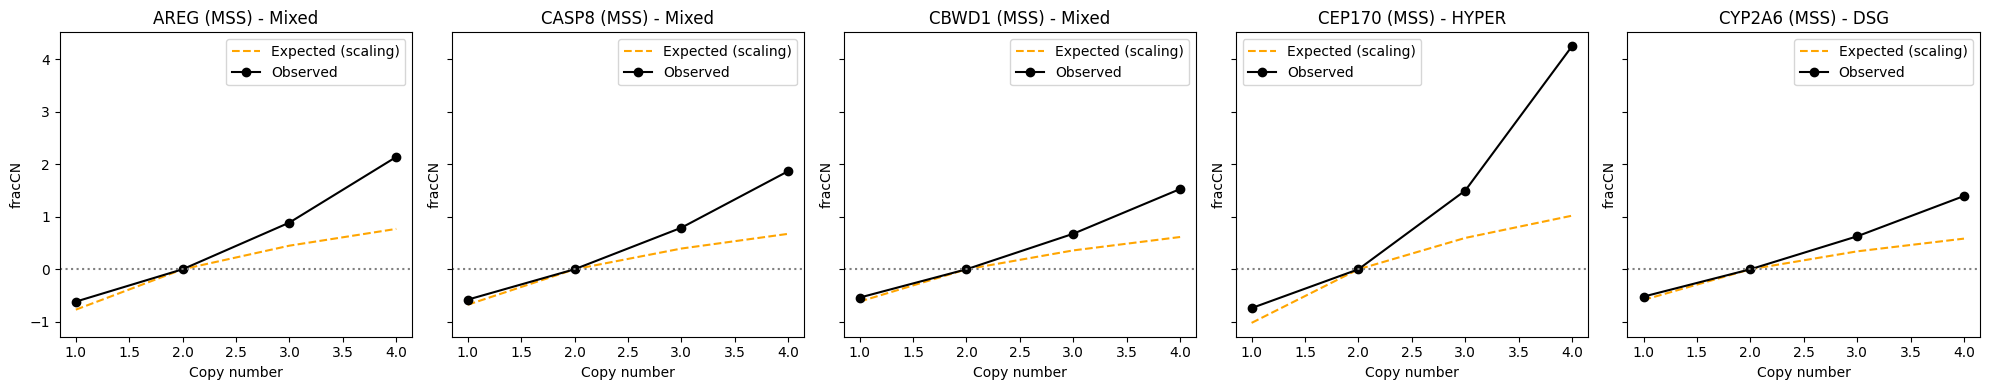

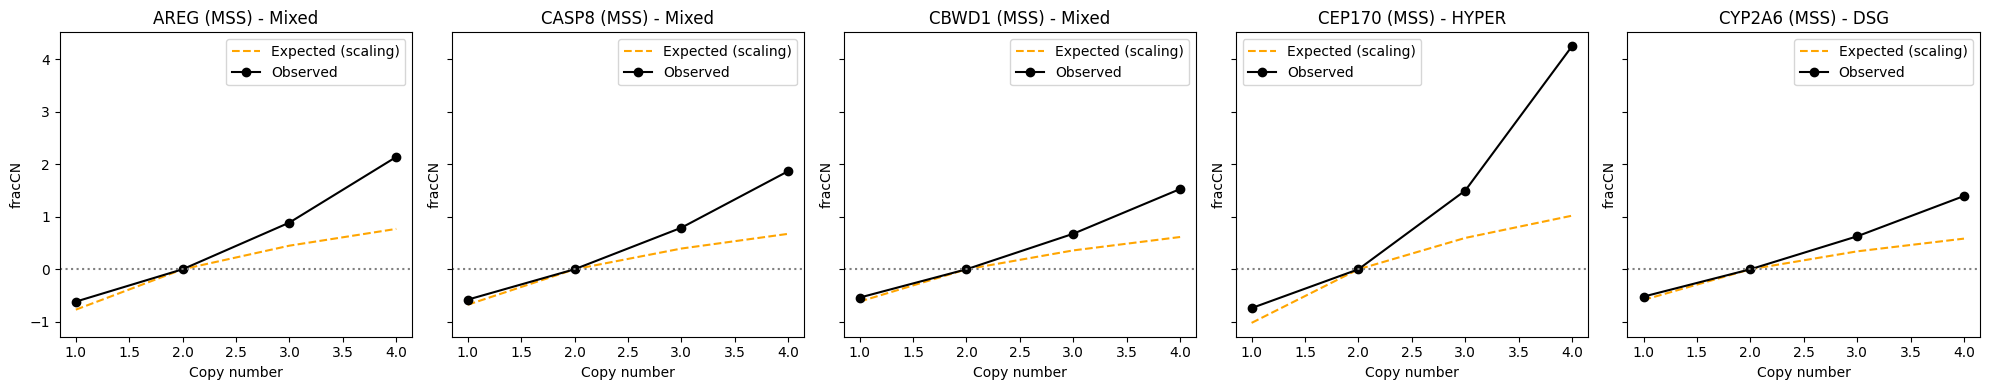

In [50]:
mixed = df_interpreted[
    (df_interpreted["response_class_MSS"] == "Mixed") |
    (df_interpreted["response_class_MSI"] == "Mixed")
]

# pick a few
genes = mixed["gene"].head(5).tolist()

plot_gene_panel(df_interpreted, genes, subtype="MSS")

<Axes: title={'center': 'ci_2to4_MSS'}, xlabel='response_class_MSS'>

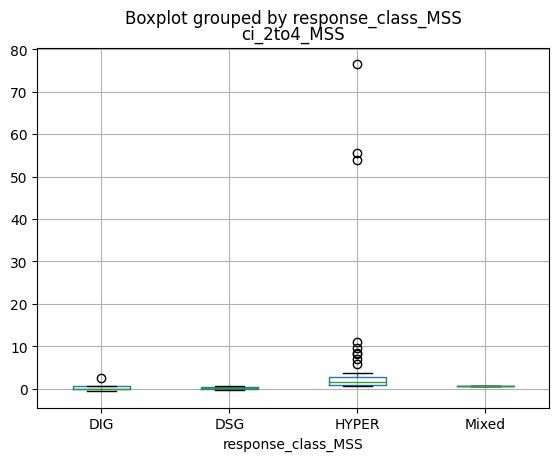

In [62]:
# CI distribution by class
df_interpreted.boxplot(column="ci_2to4_MSS", by="response_class_MSS")

<Axes: title={'center': 'fracCN_2to4_median_MSI'}, xlabel='response_class_MSI'>

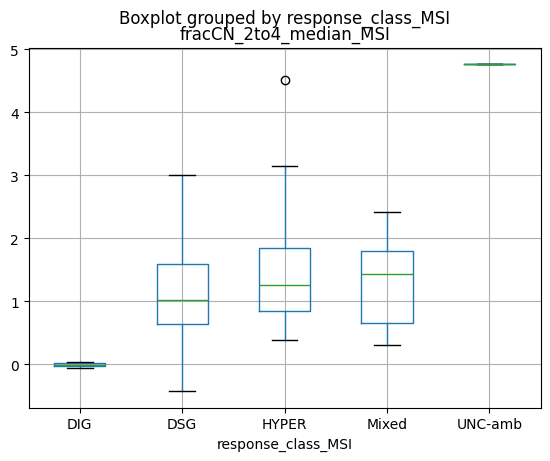

In [60]:
# fracCN vs class
df_interpreted.boxplot(column="fracCN_2to4_median_MSI", by="response_class_MSI")